In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
df= pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

Check the size of rows and columns of the dataset

In [4]:
df.shape

(74, 20)

Now let's see how many columns have null values in total.

In [5]:
df.isna().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

**Which team won the most matches?**

/var/folders/6l/65cwxjvx5zg5ssk6xb0pr7kr0000gn/T/ipykernel_6944/1456996323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['match_winner'],palette='viridis')


Text(0.5, 1.0, 'Matches Won by Teams')

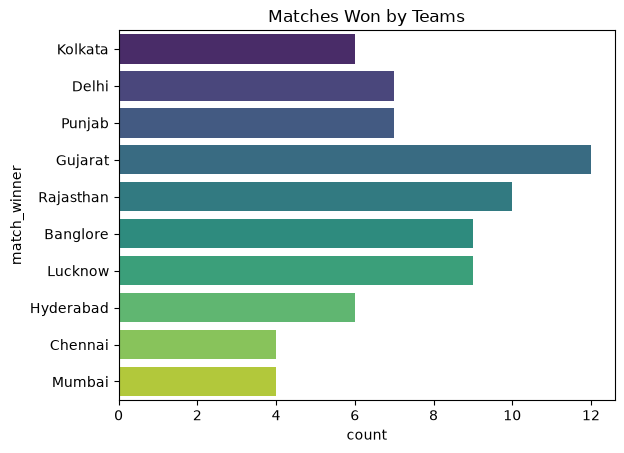

In [35]:
match_wins=df['match_winner'].value_counts()
sns.countplot(df['match_winner'],palette='viridis')
plt.title('Matches Won by Teams')

**Toss Decision Trends**

/var/folders/6l/65cwxjvx5zg5ssk6xb0pr7kr0000gn/T/ipykernel_6944/3330939525.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['toss_decision'],palette='rainbow')


<Axes: xlabel='toss_decision', ylabel='count'>

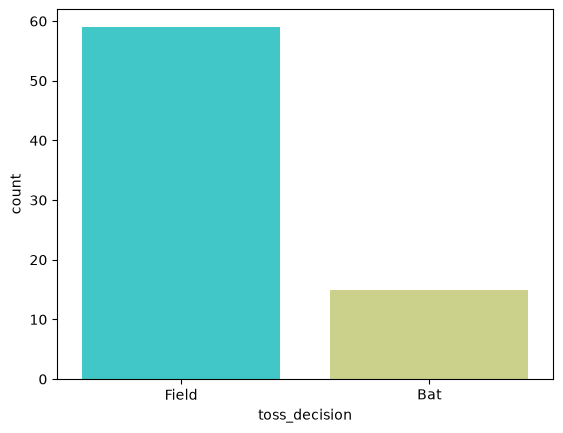

In [32]:
sns.countplot(x=df['toss_decision'],palette='rainbow')

**Toss Winner vs Match Winner**

<Axes: ylabel='count'>

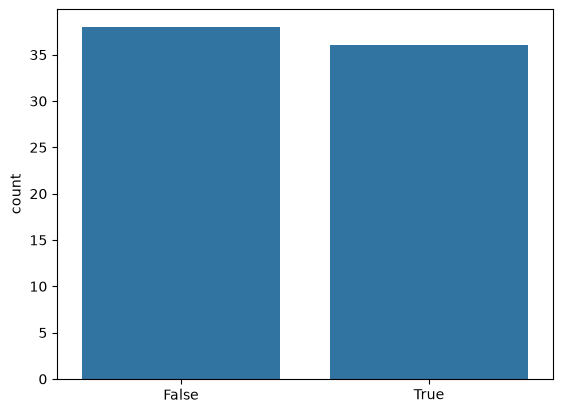

In [40]:
sns.barplot((df['toss_winner']==df['match_winner']).value_counts())

**How do teams win? (Runs vs Wickets)**

<Axes: xlabel='won_by', ylabel='count'>

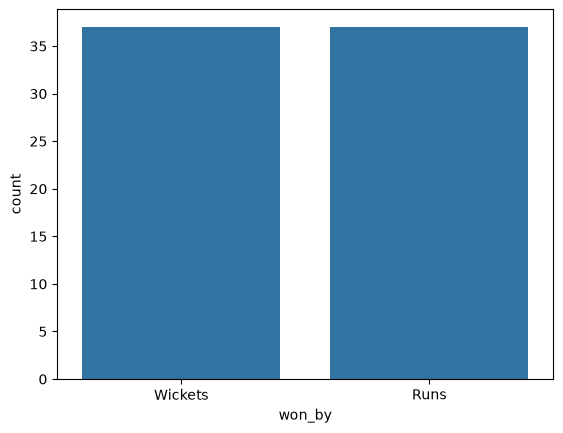

In [43]:
sns.countplot(x=df['won_by'])

**Key Player Performances**

**1 Most "Player of the Match" Awards**

/var/folders/6l/65cwxjvx5zg5ssk6xb0pr7kr0000gn/T/ipykernel_6944/698390236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=count.index,x=count.values,palette='rainbow')


<Axes: ylabel='player_of_the_match'>

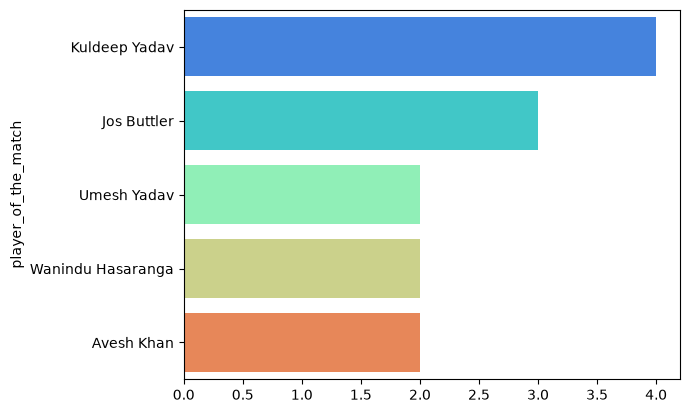

In [57]:
count=df['player_of_the_match'].value_counts().head()
sns.barplot(y=count.index,x=count.values,palette='rainbow')

**Top Scorers**

/var/folders/6l/65cwxjvx5zg5ssk6xb0pr7kr0000gn/T/ipykernel_6944/3774513079.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=count.index,x=count.values,palette='rainbow')


<Axes: ylabel='top_scorer'>

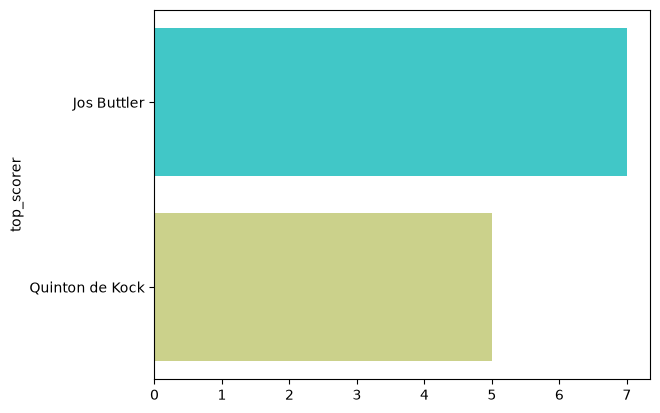

In [60]:
count=df['top_scorer'].value_counts().head(2)
sns.barplot(y=count.index,x=count.values,palette='rainbow')

**10 Best Bowling Figures**

In [87]:
def calcWicket(text):
    text=str(text)
    return int(text.split('--')[0])

In [88]:
def calcRun(text):
    text=str(text)
    return int(text.split('--')[1])

In [89]:
df['best_bowling_figure_wickets']=df['best_bowling_figure'].apply(calcWicket)
df['best_bowling_figure_runs']=df['best_bowling_figure'].apply(calcRun)

In [90]:
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,best_bowling_figure_wickets,best_bowling_figure_runs
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3,18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2,59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3,25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,...,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26,3,26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,...,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14,1,14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,...,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43,3,43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,...,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22,3,22


In [124]:
df.sort_values(by=['best_bowling_figure_wickets','best_bowling_figure_runs'],ascending=[False,True]).head(10)[['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
55,Jasprit Bumrah,5--10
53,Wanindu Hasaranga,5--18
39,Umran Malik,5--25
29,Yuzvendra Chahal,5--40
34,Andre Russell,4--5
40,Kuldeep Yadav,4--14
44,Mohsin Khan,4--16
5,Wanindu Hasaranga,4--20
38,Kuldeep Sen,4--20
7,Umesh Yadav,4--23


In [106]:
count=df['venue'].value_counts()

/var/folders/6l/65cwxjvx5zg5ssk6xb0pr7kr0000gn/T/ipykernel_6944/1584258246.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=count.index,x=count.values,palette='rainbow')


<Axes: ylabel='venue'>

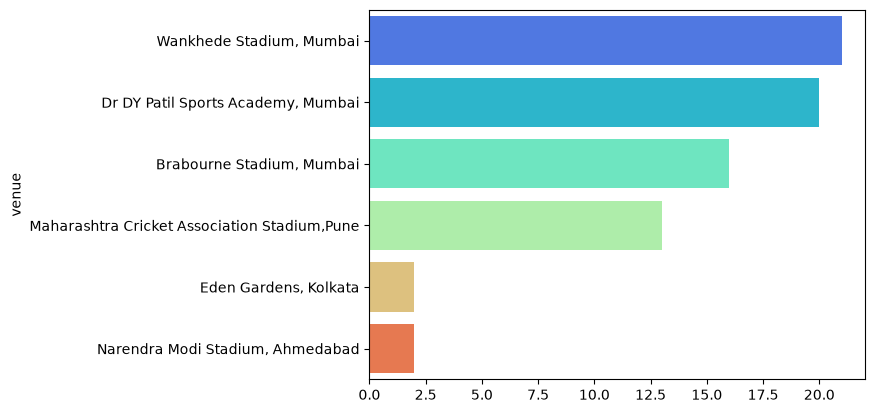

In [113]:
sns.barplot(y=count.index,x=count.values,palette='rainbow')

**Custom Questions & Insights**

**Q1: Who won the highest margin by runs?**

In [116]:
df[df['margin']==df['margin'].max()][['match_winner','margin']]

,match_winner,margin
54,Chennai,91


In [118]:
df[df['highscore']==df['highscore'].max()][['highscore','top_scorer']]

,highscore,top_scorer
65,140,Quinton de Kock


In [127]:
df.head(1)[['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
55,Jasprit Bumrah,5--10
